## Imports

In [8]:
from pathlib import Path
import numpy as np
import numpy.polynomial as nppoly
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import seaborn as sns
import scipy.optimize as spopt
import sklearn.preprocessing as skpre
import sklearn.linear_model as sklin
import sklearn.metrics as skmet
from sklearn.feature_selection import RFE

In [2]:
plt.rcParams.update({
    "figure.autolayout": True,
})

from IPython.core import display
from IPython.core.display import HTML
HTML("<style>.container { width:100% !important; }</style>")

## Constants

In [3]:
DATA_DIR = Path("../data")
DATA_FILE = DATA_DIR / "train.csv"
ELEM_FILE = DATA_DIR / "unique_m.csv"

TARGET = "critical_temp"

## Data loading

In [4]:
data_obj = pl.read_csv(DATA_FILE, infer_schema_length=1000) # Data with general features and critical temperature
elem_obj = pl.read_csv(ELEM_FILE, infer_schema_length=1000000) # Data with chemical composition

In [5]:
features = [col for col in data_obj.columns if col != TARGET]

## Polynomial fit of features

In [6]:
def power_func(x, a, nu, b):
    return a*np.power(x, nu) + b

In [7]:
exps = np.ones(len(features))
i = 0

for feature in features:
    print(feature)
    print(data_obj[feature].shape)
    
    lin_poly = nppoly.polynomial.Polynomial.fit(data_obj[feature], data_obj[TARGET], 1)
    y_lin = lin_poly(data_obj[feature])
    r2_lin = skmet.r2_score(data_obj[TARGET], y_lin)*100
    print("Linear R2 score: ", r2_lin)
    
    try:
        popt, pcov = spopt.curve_fit(power_func, data_obj[feature], data_obj[TARGET])
        y_power = power_func(data_obj[feature], popt[0], popt[1], popt[2])
        print("Optimal exponent: ", popt[1])
        r2_curve = skmet.r2_score(data_obj[TARGET], y_power)*100
        print("Curve R2 score: ", r2_curve)
    
        if np.abs(r2_curve - r2_lin) > 2:
            exps[i] = popt[1]
    except RuntimeError as e:
        # Polynomial fit failed, use this feature linearly
        pass
    i += 1

number_of_elements
(21263,)
Linear R2 score:  36.12834269911199
Optimal exponent:  0.9533576994548442
Curve R2 score:  36.133159586788835
mean_atomic_mass
(21263,)
Linear R2 score:  1.2887527458014691
wtd_mean_atomic_mass
(21263,)
Linear R2 score:  9.751381424961513
gmean_atomic_mass
(21263,)
Linear R2 score:  5.305899156697214
wtd_gmean_atomic_mass
(21263,)
Linear R2 score:  13.679522471760851
Optimal exponent:  1.0803425637436608
Curve R2 score:  13.696949423021543
entropy_atomic_mass
(21263,)
Linear R2 score:  29.552206208994956
Optimal exponent:  1.8027492670604426
Curve R2 score:  31.19550214304484
wtd_entropy_atomic_mass
(21263,)
Linear R2 score:  39.30417285670502
Optimal exponent:  1.9628219554826396
Curve R2 score:  42.68020368987327
range_atomic_mass
(21263,)
Linear R2 score:  24.203429527320107
Optimal exponent:  1.2403212204212821
Curve R2 score:  24.40074262167612
wtd_range_atomic_mass
(21263,)
Linear R2 score:  11.365757090098583
Optimal exponent:  0.9284971084288228
Curv

/home/yasharh/code/superconductivity-identifier/.venv/lib/python3.12/site-packages/polars/series/series.py:1709: RuntimeWarning: divide by zero encountered in power
  lambda out: ufunc(*args, out=out, dtype=dtype_char, **kwargs),


Optimal exponent:  0.8712554997974374
Curve R2 score:  15.162267268789654
range_fie
(21263,)
Linear R2 score:  36.094908079821565
Optimal exponent:  1.09311984703286
Curve R2 score:  36.14555153959223
wtd_range_fie
(21263,)
Linear R2 score:  9.02897018978459
Optimal exponent:  1.380675171798315
Curve R2 score:  9.133598263741638
std_fie
(21263,)
Linear R2 score:  29.355136873874955
Optimal exponent:  0.8776149214567975
Curve R2 score:  29.455935133938393
wtd_std_fie
(21263,)
Linear R2 score:  33.87394295072544
Optimal exponent:  1.068414962179145
Curve R2 score:  33.89333715404472
mean_atomic_radius
(21263,)
Linear R2 score:  1.1082338735774244
wtd_mean_atomic_radius
(21263,)
Linear R2 score:  8.837071199701207
gmean_atomic_radius
(21263,)
Linear R2 score:  2.0669876547701915
wtd_gmean_atomic_radius
(21263,)
Linear R2 score:  16.416727599704807
Optimal exponent:  0.6931598727026258
Curve R2 score:  16.445032774297317
entropy_atomic_radius
(21263,)
Linear R2 score:  31.24110600623744
Op

/home/yasharh/code/superconductivity-identifier/.venv/lib/python3.12/site-packages/polars/series/series.py:1709: RuntimeWarning: divide by zero encountered in power
  lambda out: ufunc(*args, out=out, dtype=dtype_char, **kwargs),


Optimal exponent:  0.3018372528316677
Curve R2 score:  6.236430404235261
std_ElectronAffinity
(21263,)
Linear R2 score:  6.869823343747883
Optimal exponent:  0.4220293235067775
Curve R2 score:  9.711876461043545
wtd_std_ElectronAffinity
(21263,)
Linear R2 score:  9.931784599888005
Optimal exponent:  0.46859705971607246
Curve R2 score:  12.792802739492792
mean_FusionHeat
(21263,)
Linear R2 score:  14.861738871434515
Optimal exponent:  0.10550284110587674
Curve R2 score:  18.92735276379488
wtd_mean_FusionHeat
(21263,)
Linear R2 score:  15.532816420830542
Optimal exponent:  0.030783969881205842
Curve R2 score:  22.421366096241847
gmean_FusionHeat
(21263,)
Linear R2 score:  18.644658663580206
Optimal exponent:  0.21187139631238505
Curve R2 score:  23.60237069164469
wtd_gmean_FusionHeat
(21263,)
Linear R2 score:  18.693906947174032
Optimal exponent:  0.1018980434622206
Curve R2 score:  27.312377479293957
entropy_FusionHeat
(21263,)
Linear R2 score:  30.54869127805282
Optimal exponent:  1.87

...

Optimal exponent:  4.4691936885138e-06
Curve R2 score:  0.08237541572859719
mean_ThermalConductivity
(21263,)
Linear R2 score:  14.123530384009452
Optimal exponent:  0.3908358677784169
Curve R2 score:  16.378466762381137
wtd_mean_ThermalConductivity
(21263,)
Linear R2 score:  14.389584417587232
Optimal exponent:  0.31922268275753723
Curve R2 score:  17.904736310670998
gmean_ThermalConductivity
(21263,)
Linear R2 score:  14.991788336107792
Optimal exponent:  0.7468709668916156
Curve R2 score:  15.618814655726753
wtd_gmean_ThermalConductivity
(21263,)
Linear R2 score:  13.80876413151505
Optimal exponent:  0.35046212334994015
Curve R2 score:  17.727757898005013
entropy_ThermalConductivity
(21263,)
Linear R2 score:  0.7372295701764342
Optimal exponent:  3.7831689850153504e-08
Curve R2 score:  -81.34755996890632
wtd_entropy_ThermalConductivity
(21263,)
Linear R2 score:  1.3625329813701903


/home/yasharh/code/superconductivity-identifier/.venv/lib/python3.12/site-packages/polars/series/series.py:1709: RuntimeWarning: divide by zero encountered in power
  lambda out: ufunc(*args, out=out, dtype=dtype_char, **kwargs),
/home/yasharh/code/superconductivity-identifier/.venv/lib/python3.12/site-packages/polars/series/series.py:1709: RuntimeWarning: divide by zero encountered in power
  lambda out: ufunc(*args, out=out, dtype=dtype_char, **kwargs),


Optimal exponent:  1.6296491376809147e-07
Curve R2 score:  -80.89754479589072
range_ThermalConductivity
(21263,)
Linear R2 score:  47.286790261999286
wtd_range_ThermalConductivity
(21263,)
Linear R2 score:  22.049747073491744
Optimal exponent:  0.48900306383608705
Curve R2 score:  26.412443051192103
std_ThermalConductivity
(21263,)
Linear R2 score:  42.72347673010268
Optimal exponent:  1.2907079055029895
Curve R2 score:  43.01795420785252
wtd_std_ThermalConductivity
(21263,)
Linear R2 score:  52.0231969666495
Optimal exponent:  1.9253215377051247
Curve R2 score:  54.12805595208455
mean_Valence
(21263,)
Linear R2 score:  36.010184511165775
Optimal exponent:  -0.794786265453299
Curve R2 score:  40.490233293524625
wtd_mean_Valence
(21263,)
Linear R2 score:  39.9931046420812
Optimal exponent:  -1.3097742037737814
Curve R2 score:  47.50251049380181
gmean_Valence
(21263,)
Linear R2 score:  32.840699636459014
Optimal exponent:  -0.6251541517989876
Curve R2 score:  36.6194956264399
wtd_gmean_V

/home/yasharh/code/superconductivity-identifier/.venv/lib/python3.12/site-packages/polars/series/series.py:1709: RuntimeWarning: divide by zero encountered in power
  lambda out: ufunc(*args, out=out, dtype=dtype_char, **kwargs),
/home/yasharh/code/superconductivity-identifier/.venv/lib/python3.12/site-packages/polars/series/series.py:1709: RuntimeWarning: divide by zero encountered in power
  lambda out: ufunc(*args, out=out, dtype=dtype_char, **kwargs),
/home/yasharh/code/superconductivity-identifier/.venv/lib/python3.12/site-packages/polars/series/series.py:1709: RuntimeWarning: divide by zero encountered in power
  lambda out: ufunc(*args, out=out, dtype=dtype_char, **kwargs),


Optimal exponent:  4.920294033416179e-07
Curve R2 score:  -74.62487159516577
wtd_std_Valence
(21263,)
Linear R2 score:  9.001680876873042
Optimal exponent:  2.833577220674512e-08
Curve R2 score:  -80.91819251117694


In [9]:
poly_features = np.zeros([data_obj.shape[0], len(features)])

for i, feature in enumerate(features):
    poly_features[:, i] = np.power(data_obj[feature], exps[i])

## RFE with polynomial data and a linear model

In [10]:
target_values = data_obj.select(TARGET)

model = sklin.LinearRegression()

selector = RFE(model, n_features_to_select=40)
model = selector.fit(poly_features, target_values)

## Evaluation

In [11]:
predictions = model.predict(poly_features)

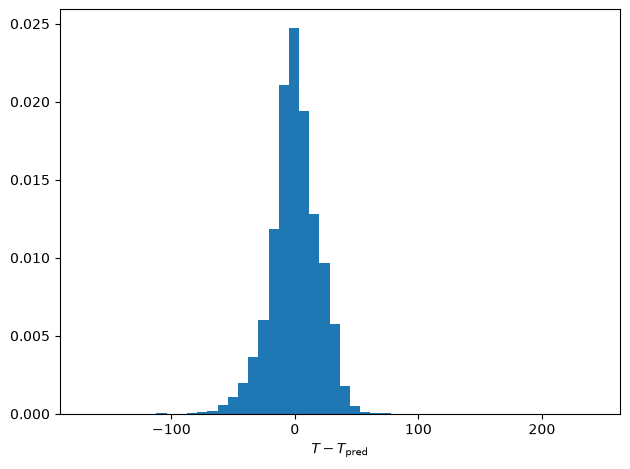

In [12]:
fig, ax = plt.subplots()

ax.hist(target_values.to_numpy() - predictions, bins=50, density=True)

ax.set_xlabel(r"$T - T_{\text{pred}}$")

plt.show()

In [13]:
print(f"R2 score: {skmet.r2_score(target_values.to_numpy(), predictions)}")

R2 score: 0.6903418192742077
